# Common

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional
from scipy.optimize import curve_fit
import sys

np.set_printoptions(linewidth=200)

In [2]:
@dataclass
class PlotParams:
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  int = 1
    marker:     Optional[str] = None
    markersize: int = 1
    markevery:  int = 1
    label:      str = ""
    capsize:    int = None  # размер "шапочек" на концах линий погрешности

def plot_experiment(ox, oy, params):
    plt.plot(
        ox, oy,
        linestyle   = params.linestyle,
        color       = params.color,
        linewidth   = params.linewidth,
        label       = params.label,
        marker      = params.marker,
        markersize  = params.markersize,
        markevery   = params.markevery
    )

def plot_dots(ox, oy, params):
    plt.scatter(
        ox, oy,
        color       = params.color,
        label       = params.label,
        marker      = params.marker,
        s           = params.markersize,
    )

def plot_error_bars(ox, oy, ex, ey, params):
    plt.errorbar(
        ox, oy,
        xerr = ex,
        yerr = ey,
        markersize = params.markersize,
        fmt = params.marker,
        color = params.color,
        elinewidth = params.linewidth,
        capsize=params.capsize,
        capthick=params.linewidth,
    )

def round_with_uncertainty(value, uncertainty):
    order = -int(np.floor(np.log10(uncertainty)))  # Определяем порядок округления
    rounded_value = round(value, order)
    rounded_uncertainty = round(uncertainty, order)
    return rounded_value, rounded_uncertainty

def scale_to_scientific(val, sigm):
    val_rounded, sigm_rounded = round_with_uncertainty(val, sigm)
    scale_order = -int(np.floor(np.log10(abs(val_rounded))))  # Определяем порядок числа
    if scale_order != 0:
        latex_value = val_rounded * 10**scale_order
        latex_uncertainty = sigm_rounded * 10**scale_order
        varepsilon = np.abs(latex_uncertainty / latex_value * 100)
    else:
        varepsilon = np.abs(sigm_rounded / val_rounded * 100)

    return val_rounded, sigm_rounded, latex_value, latex_uncertainty, scale_order, varepsilon

def print_latex(val, sigm, parameter_name):
    val_rounded, sigm_rounded, latex_value, latex_uncertainty, scale_order, varepsilon = scale_to_scientific(val, sigm)
    print(f"------------ {parameter_name} ------------")
    print(f"{parameter_name} = {val} ± {sigm}")
    print(f"{parameter_name}_rounded = {val_rounded} ± {sigm_rounded}")
    if scale_order != 0:
        if scale_order > 0:
            print(f"= $\\left( {latex_value:.3f} \\pm {latex_uncertainty:.3f} \\right) \\cdot 10^{{-{scale_order}}}$, \\ $ (\\varepsilon = {varepsilon:.2f} $\\%)")
        else:
            print(f"= $\\left( {latex_value:.3f} \\pm {latex_uncertainty:.3f} \\right) \\cdot 10^{{{-scale_order}}}$, \\ $ (\\varepsilon = {varepsilon:.2f} $\\%)")
    else:
        print(f"= $\\left( {val_rounded:.4f} \\pm {sigm_rounded:.4f} \\right)$, \\ $(\\varepsilon = {varepsilon:.2f}$ \\%)")
    print()

def read_data(filename, func, arguments, error_type, error_x, error_y):
    data = np.loadtxt(filename)
    xdata = data[:, 0]
    ydata = data[:, 1]

    popt, pcov = curve_fit(func, xdata, ydata)

    sigm_arr = np.sqrt(np.diag(pcov))

    for arg, val, sigm in zip(arguments, popt, sigm_arr):
        print_latex(val, sigm, arg)


    # Если погрешности в процентах
    if error_type == 'percent':
        xerr = error_x * xdata  # Погрешность по X в процентах
        yerr = error_y * ydata  # Погрешность по Y в процентах
    # Если погрешности в абсолютных значениях
    elif error_type == 'absolute':
        xerr = np.full_like(xdata, error_x)  # Погрешность по X в абсолютных значениях
        yerr = np.full_like(ydata, error_y)  # Погрешность по Y в абсолютных значениях
    else:
        xerr = None
        yerr = None

    x_min = min(xdata)
    x_max = max(xdata)

    x_fit = np.linspace(x_min, x_max, 1000)
    y_fit = func(x_fit, *popt)

    return xdata, ydata, xerr, yerr, x_fit, y_fit, popt, sigm_arr

# Settings

In [ ]:
filename = 'data.txt'
filename_to_save = "example.pdf"

error_type = None  # "percent" (0 --- 1) or "absolute" (0 --- inf) or None
error_x = 2  # Погрешность по X
error_y = 0.0000000001  # Погрешность по Y

In [1436]:
# arguments = ['a']
# def func_ax(x, a):
#     return a * x

# arguments = ['a', 'b']
# def func_axpb(x, a, b):
#     return a * x + b

arguments = ['y0', 'C', 'x0']
def func_gartman(x, y0, C, x0):
    return y0 + C / (x - x0)

# arguments = ['a', 'b', 'c', 'd']
# def polinomial_func(x, a, b, c, d):
#     return a * x**3 + b * x**2 + c * x + d

# arguments = ['y0', 'power', 'bias']
# def exponential_func(x, y0, power, bias):
#     return y0 * np.exp(power * x) + bias

In [1437]:
func = func_gartman

# Run

In [1438]:
xdata, ydata, xerr, yerr, x_fit, y_fit, popt, sigm_arr = read_data(filename, func, arguments, error_type, error_x, error_y)

------------ y0 ------------
y0 = 4027.4569712257703 ± 302.80502819882076
y0_rounded = 4000.0 ± 300.0
= $\left( 4.000 \pm 0.300 \right) \cdot 10^{3}$, \ $ (\varepsilon = 7.50 $\%)

------------ C ------------
C = -8403995.920630898 ± 2424437.6925172103
C_rounded = -8000000.0 ± 2000000.0
= $\left( -8.000 \pm 2.000 \right) \cdot 10^{6}$, \ $ (\varepsilon = 25.00 $\%)

------------ x0 ------------
x0 = 1291.6696929770287 ± 549.2909696604686
x0_rounded = 1300.0 ± 500.0
= $\left( 1.300 \pm 0.500 \right) \cdot 10^{3}$, \ $ (\varepsilon = 38.46 $\%)



# Graph

In [ ]:
markevery_i = 1

plot_args_dict = {
    "Fitted":  PlotParams(linestyle = "--", color = "black", linewidth = 1, marker=None, markersize=7, markevery = markevery_i, label = r'$\theta = \theta_0 + \frac{C}{\lambda - \lambda_0}$'),
    "Dots": PlotParams(color = "black", marker="*", markersize=130, markevery = markevery_i, label = "Dots"),
    "Error_bars": PlotParams(color = "black", linewidth=2, marker="*", markersize=9, capsize=3),
}

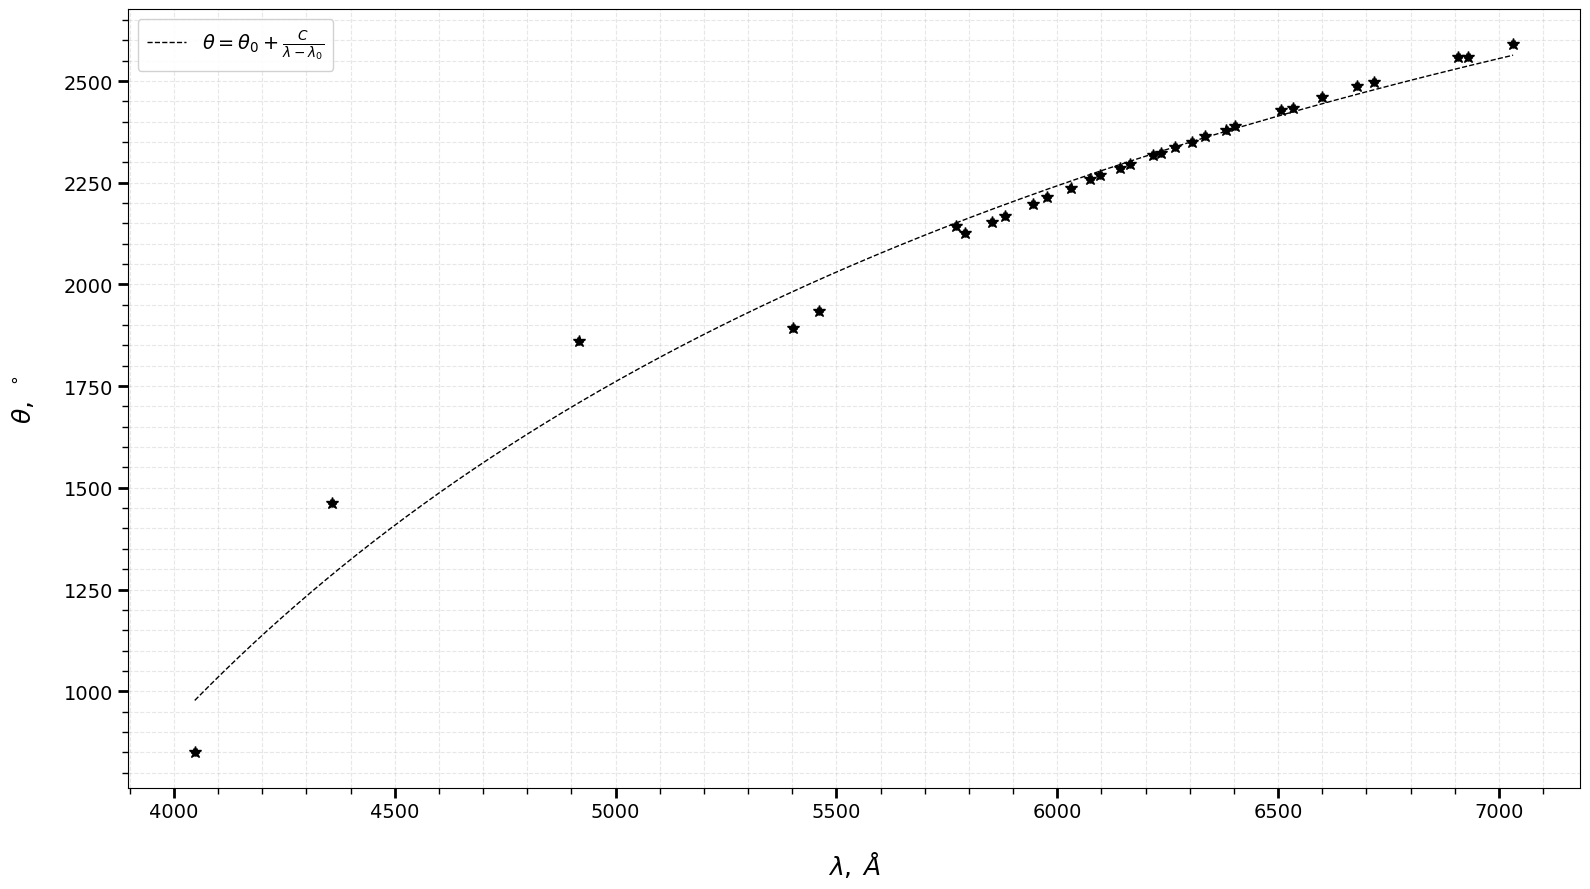

In [1440]:
plt.figure(figsize=[16, 9])

plot_experiment(x_fit, y_fit, plot_args_dict["Fitted"])

if error_type in ['percent', 'absolute']:
    plot_error_bars(xdata, ydata, xerr, yerr, plot_args_dict["Error_bars"])
else:
    plot_dots(xdata, ydata, plot_args_dict["Dots"])

# plt.title('Example', fontsize=20, pad=20)
plt.xlabel(r'$\lambda, \; \AA$', fontsize=18, labelpad=20)
plt.ylabel(r'$\theta, \; ^\circ$', fontsize=18, labelpad=20)
# plt.yscale('log')
# plt.xscale('log')
plt.minorticks_on()
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9, borderpad=0.5)
plt.tick_params(axis='both', which='major', labelsize=14, length=7, width=2)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4, width=1)
plt.tight_layout()

plt.savefig(filename_to_save)

plt.show()
plt.close()